# 01. Raw 데이터 EDA 및 품질 진단

## 분석 개요

- 목적: 본격 퍼널 분석 전에 `events`의 구조·분포·추이·이상값·반복·세션 무결성을 들여다보고, 이후 분석이 공유할 처리 방침의 근거를 만든다.
- 방식: **집계는 전부 MySQL(SQL)에서 수행하고, 노트북은 그 소량 결과만 받아 확인·시각화한다.** 2천만 행을 pandas로 올리지 않는다.
- 분석 단위: 항목마다 이벤트·세션·사용자 단위를 명시한다(혼용하지 않는다).
- 관측 기간: 2019-10-01 - 2020-02-29 (연속 5개월).
- 성능: `run()`은 실행시간을 출력하고 결과를 `cache/{name}.parquet`에 캐시한다(`refresh=True`로 갱신). 캐시 엔진(pyarrow 등)이 없으면 캐시 없이 동작한다.
- 참고: 결과 수치는 아래 셀 실행 출력에서 확정한다(마크다운 관찰·결론은 실행 후 작성).

### 품질 진단과 후속 처리 연결

2천만 행 raw를 pandas로 적재해 `info()`·`shape`를 확인하는 대신, 데이터 규모·결측·반복·이상값을 MySQL에서 집계한다. 이 단계에서는 raw를 수정하지 않고 처리 방침만 확정하며, 실제 제외·변환은 02 마트 생성 SQL에서 집행한다.

| 진단 영역 | 01 확인 내용 | 확정한 처리 방침 |
|---|---|---|
| 규모·기간 | 전체 이벤트 행수, 관측 기간, 고유 사용자·세션 수 | raw 원본을 유지하고 집계 결과만 노트북으로 불러온다. |
| 결측 | `category_code`·`brand`·`user_session` 등 컬럼별 NULL 규모 | `user_session` NULL은 세션 지표에서 제외하고, 카테고리 키는 `category_id`를 사용하며, 상품 마트의 brand 결측은 `unknown`으로 보존한다. |
| 가격 이상값 | 음수·0원·양수 가격의 규모와 이벤트 유형·기간별 집중 여부 | 음수 가격은 이벤트 카운트와 revenue에서 제외하고, 0원은 이벤트 카운트에 포함하되 revenue에서는 제외한다. |
| 반복 이벤트 | 동일 시각·사용자·세션·상품·이벤트 유형 조합의 반복 규모 | 대표행 선택에 추가 가정이 필요하므로 임의 제거하지 않고 해석 시 반복 가능성을 병기한다. |
| 세션 무결성 | 세션당 고유 사용자 수와 세션 지속시간 분포 | `user_session`이 있고, 사용자 1명에 대응하며, 지속시간이 1일 이하인 세션만 유효 세션으로 사용한다. |

세부 수치와 근거는 각 진단 셀에서 확인하고, 최종 정의는 `docs/metrics.md`를 단일 원천으로 사용한다.

In [1]:
import os
import re
import time
from pathlib import Path
from urllib.parse import quote_plus

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv()  # 프로젝트 루트의 .env 자동 탐색
engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{quote_plus(os.getenv('DB_PASSWORD'))}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}?charset=utf8mb4"
)

In [2]:
# 실행 위치(cwd)가 notebooks/ 든 프로젝트 루트든 sql 파일을 찾도록 처리
def find_sql(name):
    for base in (Path.cwd(), Path.cwd().parent):
        cand = base / 'sql' / name
        if cand.exists():
            return cand
    raise FileNotFoundError(f'sql/{name} 을(를) 찾지 못함 (cwd={Path.cwd()})')

SQL_FILE = find_sql('01_raw_eda.sql')
CACHE_DIR = SQL_FILE.parent.parent / 'cache'  # 프로젝트 루트/cache (재생성 가능)

def load_queries(path):
    body = Path(path).read_text(encoding='utf-8')
    parts = re.split(r'(?m)^--\s*name:\s*(\w+).*$', body)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

Q = load_queries(SQL_FILE)

def run(name, refresh=False, **kwargs):
    # 캐시 우선(있고 refresh=False), 없으면 SQL 실행 후 parquet 캐시 저장
    cache_path = CACHE_DIR / f'{name}.parquet'
    if cache_path.exists() and not refresh:
        try:
            df = pd.read_parquet(cache_path)
            print(f"[{name}] 캐시 로드 · {len(df):,}행")
            return df
        except Exception:
            pass  # 캐시 엔진 없거나 손상 시 재실행
    t0 = time.time()
    df = pd.read_sql(text(Q[name]), engine, **kwargs)
    elapsed = time.time() - t0
    try:
        CACHE_DIR.mkdir(exist_ok=True)
        df.to_parquet(cache_path, index=False)
        note = '→ 캐시 저장'
    except Exception as e:
        note = f'(캐시 미저장: {type(e).__name__} — parquet 엔진 필요)'
    print(f"[{name}] 실행 {elapsed:.1f}s · {len(df):,}행 {note}")
    return df

# 이벤트 유형 공통 색상 (퍼널 팔레트)
color_map = {'view': '#3B82F6', 'cart': '#F59E0B', 'remove_from_cart': '#EF4444', 'purchase': '#10B981'}

---
## 1. 데이터 규모·기간

전체 행수·관측 기간과 고유 사용자·세션 수를 확인한다. 고유 수는 인덱스 커버링을 위해 별도 쿼리로 분리했다.

- 이벤트 단위(행수·기간) / 사용자·세션 단위(고유 수).

In [3]:
base = run('base_scalars')
base[['행수', '시작', '종료']]

[base_scalars] 실행 12.2s · 1행 → 캐시 저장


,행수,시작,종료
0,20692840,2019-10-01,2020-02-29 23:59:59


In [4]:
distinct_users = run('distinct_users')
distinct_sessions = run('distinct_sessions')
pd.concat([distinct_users, distinct_sessions], axis=1)

[distinct_users] 실행 2.4s · 1행 → 캐시 저장


[distinct_sessions] 실행 9.1s · 1행 → 캐시 저장


,고유_사용자,고유_세션
0,1639358,4535941


---
## 2. 일별 추이

일별 이벤트 수·사용자 수 추이에서 수집 누락(급감)이나 비정상 급증이 있는지 확인한다. 이 결과는 이벤트 유형 분포·가격 이상값 파생의 원천으로도 쓴다.

- 이벤트 단위. 유형별 일별 집계.

In [5]:
daily_trend = run('daily_trend')
daily_trend['event_date'] = pd.to_datetime(daily_trend['event_date'])
daily_trend.head()

[daily_trend] 실행 26.6s · 608행 → 캐시 저장


,event_date,event_type,event_count,user_count,zero_neg
0,2019-10-01,cart,46916,7676,13.0
1,2019-10-01,purchase,8476,1001,1.0
2,2019-10-01,remove_from_cart,25813,2562,2.0
3,2019-10-01,view,61209,18392,143.0
4,2019-10-02,cart,89124,22133,2.0


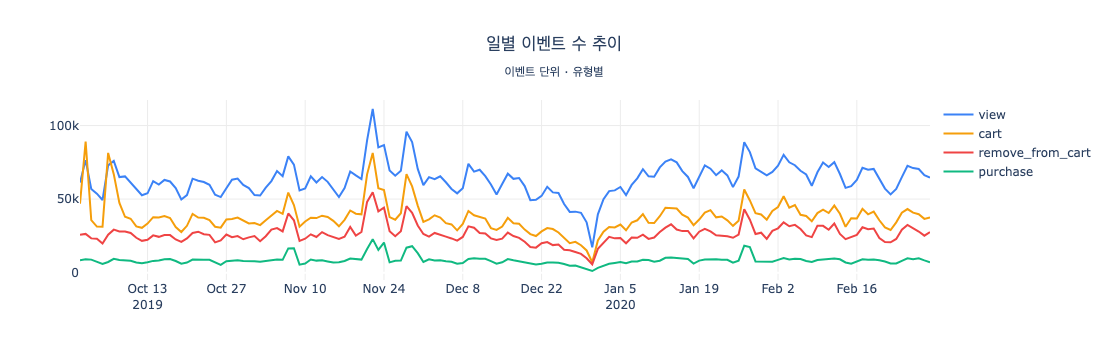

In [6]:
fig = go.Figure()
for et in ['view', 'cart', 'remove_from_cart', 'purchase']:
    d = daily_trend[daily_trend['event_type'] == et]
    fig.add_trace(go.Scatter(
        x=d['event_date'], y=d['event_count'],
        mode='lines', name=et,
        line=dict(color=color_map.get(et, '#94A3B8')),
    ))
fig.update_layout(
    title=dict(text='일별 이벤트 수 추이<br><sub>이벤트 단위 · 유형별</sub>', x=0.5, xanchor='center'),
    plot_bgcolor='white',
    xaxis=dict(gridcolor='#ececec'),
    yaxis=dict(gridcolor='#ececec'),
    legend=dict(orientation='v', x=1.01, y=1),
)
fig.show()

---
## 3. 이벤트 유형 분포

이벤트 유형별 구성과 규모를 확인한다. 별도 쿼리 없이 `daily_trend` 결과를 Python groupby로 파생한다. 단순 건수 비율은 전환율이 아니라 이벤트 구성임에 유의한다.

- 이벤트 단위. 분모는 전체 이벤트 수.

In [7]:
event_dist = (
    daily_trend
    .groupby('event_type', as_index=False)
    .agg(건수=('event_count', 'sum'))
    .sort_values('건수', ascending=False)
    .reset_index(drop=True)
)
event_dist['비율_pct'] = (event_dist['건수'] / event_dist['건수'].sum() * 100).round(2)
event_dist

,event_type,건수,비율_pct
0,view,9657821,46.67
1,cart,5768333,27.88
2,remove_from_cart,3979679,19.23
3,purchase,1287007,6.22


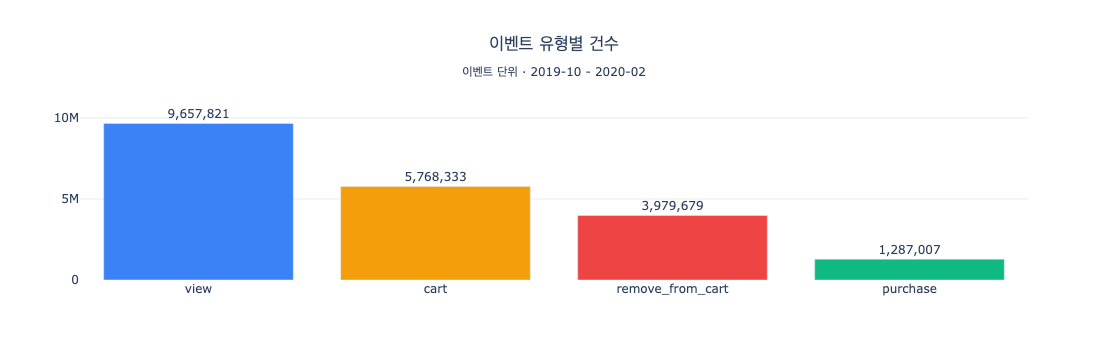

In [8]:
y = event_dist['건수']
fig = go.Figure(go.Bar(
    x=event_dist['event_type'],
    y=y,
    marker_color=[color_map.get(t, '#94A3B8') for t in event_dist['event_type']],
    text=y.map(lambda v: f"{v:,}"),
    textposition='outside',
))
fig.update_layout(
    title=dict(text='이벤트 유형별 건수<br><sub>이벤트 단위 · 2019-10 - 2020-02</sub>', x=0.5, xanchor='center'),
    plot_bgcolor='white',
    yaxis=dict(gridcolor='#ececec', range=[0, y.max() * 1.15]),
    showlegend=False,
)
fig.show()

---
## 4. 결측 프로파일

컬럼별 결측 규모를 확인한다(`base_scalars` 단일 스캔 결과에서 파생). `category_id`는 결측이 없어 카테고리 분석의 키로 쓸 수 있는지 함께 본다.

- 이벤트 단위. 분모는 전체 행수.

In [9]:
total_rows = base['행수'].iloc[0]

null_cols = ['null_category_code', 'null_brand', 'null_user_session', 'null_category_id', 'null_price']
null_tidy = base[null_cols].T.reset_index()
null_tidy.columns = ['컬럼', '결측수']
null_tidy['컬럼'] = null_tidy['컬럼'].str.replace('null_', '', regex=False)
null_tidy['결측률_pct'] = (null_tidy['결측수'] / total_rows * 100).round(3)
null_tidy

,컬럼,결측수,결측률_pct
0,category_code,20339246.0,98.291
1,brand,8757117.0,42.320
2,user_session,4598.0,0.022
3,category_id,0.0,0.000
4,price,0.0,0.000


---
## 5. 가격 이상값

`price` 부호별 분포(`base_scalars`에서 파생), 음수 가격의 정체, 이벤트 유형·월별 0 이하 비율(`daily_trend`에서 파생)을 확인한다. 가격·가치 분석의 제외 기준을 정하기 위한 진단이다.

- 이벤트 단위. 퍼널 카운트에는 포함하되, 가격·가치 지표에서만 제외 대상이 되는지 판단한다.

In [10]:
price_sign = base[['price_음수', 'price_0원', 'price_정상']]
price_sign

,price_음수,price_0원,price_정상
0,131.0,104157.0,20588552.0


In [11]:
# 음수 가격이 특정 상품·가격에 몰렸는지(반품/오류 여부) 확인
negative_price_detail = run('negative_price_detail')
negative_price_detail

[negative_price_detail] 실행 6.2s · 9행 → 캐시 저장


,product_id,brand,price,event_type,건수,최초,최종
0,5670257,None,-15.87,purchase,39,2019-10-03 18:25:39,2020-02-25 14:07:40
1,5716857,None,-23.81,purchase,34,2019-10-01 19:10:56,2020-02-26 08:33:10
2,5716859,None,-47.62,purchase,30,2019-10-03 17:37:04,2020-02-29 11:41:09
3,5716855,None,-7.94,purchase,12,2019-10-02 08:30:03,2020-02-29 07:15:17
4,5716861,None,-79.37,purchase,11,2019-10-14 17:33:24,2020-02-11 12:38:33
5,5716857,None,-23.81,remove_from_cart,2,2020-02-29 17:10:44,2020-02-29 17:11:27
6,5716857,None,-23.81,view,1,2020-01-05 10:49:53,2020-01-05 10:49:53
7,5716859,None,-47.62,remove_from_cart,1,2020-01-13 11:26:36,2020-01-13 11:26:36
8,5716861,None,-79.37,view,1,2020-01-27 08:04:32,2020-01-27 08:04:32


In [12]:
price_by_event = (
    daily_trend
    .groupby('event_type', as_index=False)
    .agg(zero_neg=('zero_neg', 'sum'), 전체=('event_count', 'sum'))
    .sort_values('zero_neg', ascending=False)
    .reset_index(drop=True)
)
price_by_event['비율_pct'] = (price_by_event['zero_neg'] / price_by_event['전체'] * 100).round(3)
price_by_event

,event_type,zero_neg,전체,비율_pct
0,cart,49370.0,5768333,0.856
1,view,30492.0,9657821,0.316
2,remove_from_cart,24299.0,3979679,0.611
3,purchase,127.0,1287007,0.010


In [13]:
dt = daily_trend.copy()
dt['월'] = dt['event_date'].dt.strftime('%Y-%m')
price_by_month = (
    dt
    .groupby('월', as_index=False)
    .agg(zero_neg=('zero_neg', 'sum'), 전체=('event_count', 'sum'))
)
price_by_month['비율_pct'] = (price_by_month['zero_neg'] / price_by_month['전체'] * 100).round(3)
price_by_month

,월,zero_neg,전체,비율_pct
0,2019-10,6086.0,4102283,0.148
1,2019-11,11642.0,4635837,0.251
2,2019-12,7607.0,3533286,0.215
3,2020-01,7662.0,4264752,0.180
4,2020-02,71291.0,4156682,1.715


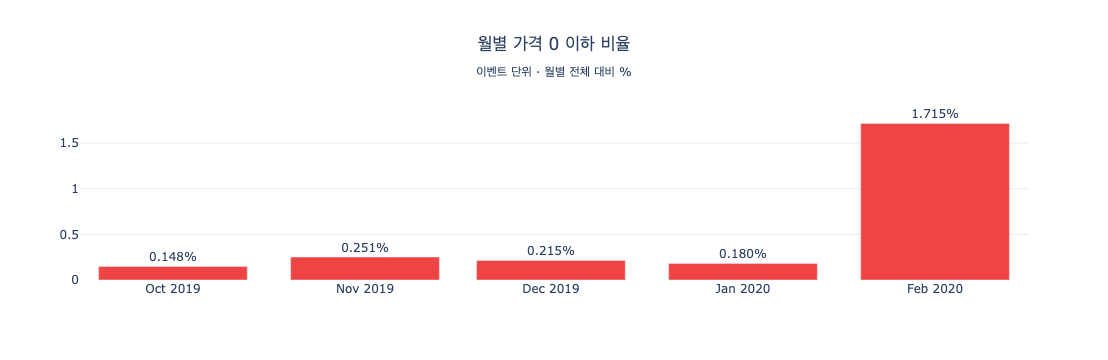

In [14]:
y = price_by_month['비율_pct']
fig = go.Figure(go.Bar(
    x=price_by_month['월'],
    y=y,
    marker_color='#EF4444',
    text=y.map(lambda v: f"{v:.3f}%"),
    textposition='outside',
))
fig.update_layout(
    title=dict(text='월별 가격 0 이하 비율<br><sub>이벤트 단위 · 월별 전체 대비 %</sub>', x=0.5, xanchor='center'),
    plot_bgcolor='white',
    yaxis=dict(gridcolor='#ececec', range=[0, y.max() * 1.15]),
)
fig.show()

---
## 6. 반복 이벤트 패턴

동일 세션·시각·상품·유형이 반복된 이벤트 규모를 유형별로 확인하고, 전체 규모는 유형별 결과의 합으로 파생한다. 완전 동일 행이 아니라 4개 키가 반복된 것이므로 제거(dedup) 기준으로 쓰지 않고 규모만 본다. purchase의 반복 비중을 중점적으로 본다.

- 이벤트 단위. `idx_repeat_events` 복합 인덱스를 사용한다.

In [15]:
repeat_by_event = run('repeat_by_event')
# 반복_포함_행수 = 반복_그룹수 + 초과_행수 (그룹당 대표 1행 + 초과분)
repeat_by_event['반복_포함_행수'] = repeat_by_event['반복_그룹수'] + repeat_by_event['초과_행수']
repeat_by_event

[repeat_by_event] 실행 13.5s · 4행 → 캐시 저장


,event_type,반복_그룹수,초과_행수,반복_포함_행수
0,remove_from_cart,953387,991821.0,1945208.0
1,cart,90502,115342.0,205844.0
2,view,969,1031.0,2000.0
3,purchase,903,905.0,1808.0


In [16]:
# 전체 규모는 유형별 결과의 합으로 파생 (기존 repeat_events와 동일 형태)
repeat_total = pd.DataFrame([{
    '반복_그룹수': repeat_by_event['반복_그룹수'].sum(),
    '반복_포함_행수': repeat_by_event['반복_포함_행수'].sum(),
    '초과_행수': repeat_by_event['초과_행수'].sum(),
}])
repeat_total

,반복_그룹수,반복_포함_행수,초과_행수
0,1045761,2154860.0,1109099.0


---
## 7. 세션당 이벤트 수 분포

세션이 보통 몇 개의 이벤트로 이루어지는지 분포를 확인한다. 단일 이벤트 세션(즉시 이탈)과 장세션의 비중을 본다.

- 세션 단위. `user_session` NULL은 제외한다.

In [17]:
session_event_dist = run('session_event_dist')
session_event_dist

[session_event_dist] 실행 10.9s · 5행 → 캐시 저장


,이벤트수_구간,세션수
0,1,2887064
1,2-3,708710
2,4-10,528825
3,11-50,355326
4,51+,56016


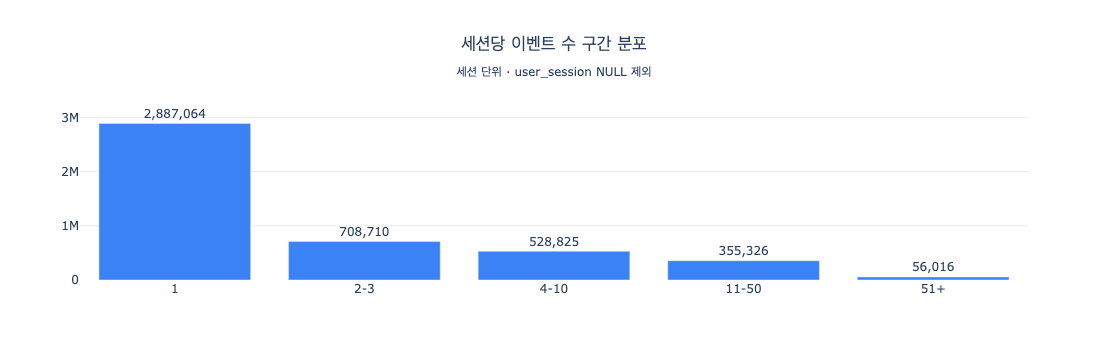

In [18]:
y = session_event_dist['세션수']
fig = go.Figure(go.Bar(
    x=session_event_dist['이벤트수_구간'],
    y=y,
    marker_color='#3B82F6',
    text=y.map(lambda v: f"{v:,}"),
    textposition='outside',
))
fig.update_layout(
    title=dict(text='세션당 이벤트 수 구간 분포<br><sub>세션 단위 · user_session NULL 제외</sub>', x=0.5, xanchor='center'),
    plot_bgcolor='white',
    yaxis=dict(gridcolor='#ececec', range=[0, y.max() * 1.15]),
)
fig.show()

---
## 8. 세션 무결성

세션이 정상 단위인지 확인한다. 하나의 세션은 한 사용자에 속해야 하고, 지속시간이 지나치게 길면 세션 정의 이상을 시사한다.

- 세션 단위. `user_session` NULL은 제외한다.

In [19]:
# 세션당 고유 user_id 수 분포 (1 vs 2+)
session_user_integrity = run('session_user_integrity')
session_user_integrity

[session_user_integrity] 실행 106.7s · 2행 → 캐시 저장


,고유user_구간,세션수
0,1,4535669
1,2+,272


In [20]:
# 세션 지속시간(시작~끝) 구간 분포
session_duration_dist = run('session_duration_dist')
session_duration_dist

[session_duration_dist] 실행 12.9s · 3행 → 캐시 저장


,지속_구간,세션수
0,<=1시간,4361378
1,<=1일,138368
2,>1일,36195


---
## 9. 사용자당 세션 수 분포

사용자가 관측 기간에 몇 개의 세션을 갖는지 분포를 확인한다.

- 사용자 단위. `user_session` NULL은 제외한다.

In [21]:
sessions_per_user_dist = run('sessions_per_user_dist')
sessions_per_user_dist

[sessions_per_user_dist] 실행 83.4s · 4행 → 캐시 저장


,세션수_구간,사용자수
0,1,1084873
1,2-3,352911
2,4-10,145423
3,11+,55944


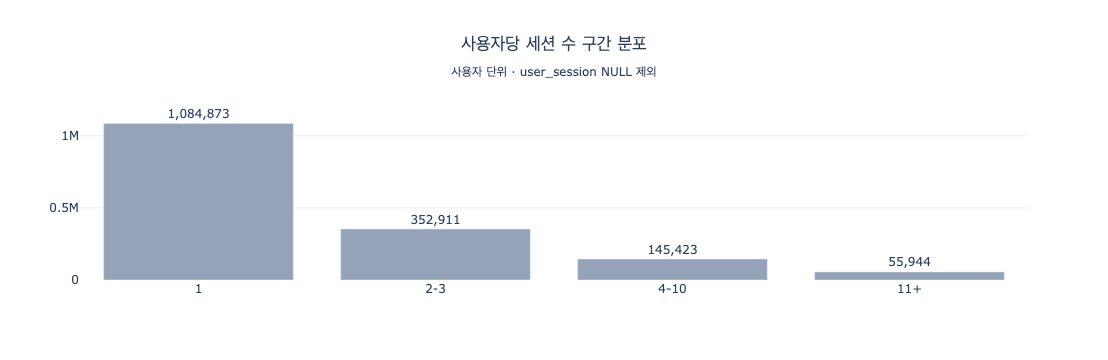

In [22]:
y = sessions_per_user_dist['사용자수']
fig = go.Figure(go.Bar(
    x=sessions_per_user_dist['세션수_구간'],
    y=y,
    marker_color='#94A3B8',
    text=y.map(lambda v: f"{v:,}"),
    textposition='outside',
))
fig.update_layout(
    title=dict(text='사용자당 세션 수 구간 분포<br><sub>사용자 단위 · user_session NULL 제외</sub>', x=0.5, xanchor='center'),
    plot_bgcolor='white',
    yaxis=dict(gridcolor='#ececec', range=[0, y.max() * 1.15]),
)
fig.show()

---
## 10. 활동량 상위 사용자

이벤트 수가 특히 많은 사용자를 확인한다. 데이터만으로 봇으로 단정하지 않고, 활동량 상위 사용자를 후속 검토 항목으로 기록한다.

- 사용자 단위. 여기서는 식별만 한다.

In [23]:
top_active_users = run('top_active_users')
top_active_users

[top_active_users] 실행 4.0s · 10행 → 캐시 저장


,user_id,이벤트수
0,527021202,26752
1,557616099,9903
2,583884978,9420
3,419558969,8283
4,476450673,8122
5,467810091,8066
6,557956487,7735
7,550388516,7556
8,552908674,7419
9,506877330,6909


---
## 11. 카디널리티·가격 분포

상품·브랜드·카테고리의 카디널리티와, `price > 0` 값의 분포를 확인한다. MySQL 8.0에는 PERCENTILE 집계가 없어 분위수 대신 로그스케일 구간 히스토그램으로 분포를 본다.

- 이벤트 단위.

In [24]:
cardinality = run('cardinality')
cardinality

[cardinality] 실행 10.7s · 1행 → 캐시 저장


,상품수,브랜드수,카테고리수
0,54571,273,525


In [25]:
price_histogram = run('price_histogram')
price_histogram

[price_histogram] 실행 10.3s · 7행 → 캐시 저장


,가격구간,건수
0,"[0,1)",2146923
1,"[1,3)",5332635
2,"[3,10)",9629062
3,"[10,30)",2498866
4,"[30,100)",791949
5,"[100,300)",187311
6,300+,1806


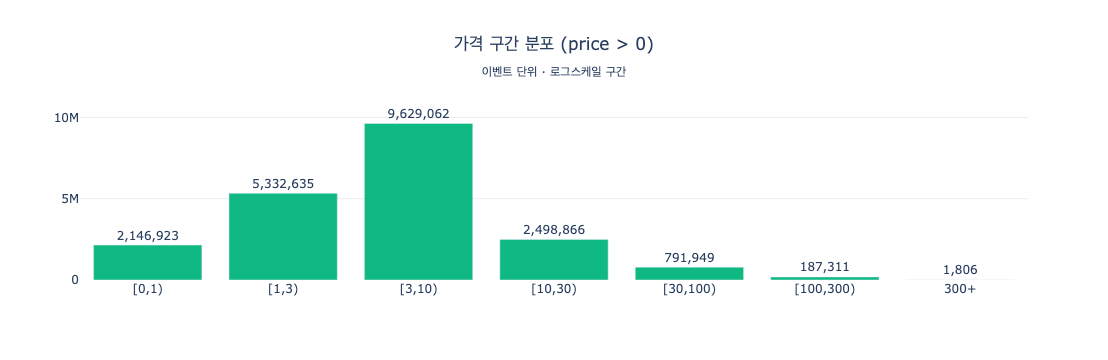

In [26]:
y = price_histogram['건수']
fig = go.Figure(go.Bar(
    x=price_histogram['가격구간'],
    y=y,
    marker_color='#10B981',
    text=y.map(lambda v: f"{v:,}"),
    textposition='outside',
))
fig.update_layout(
    title=dict(text='가격 구간 분포 (price > 0)<br><sub>이벤트 단위 · 로그스케일 구간</sub>', x=0.5, xanchor='center'),
    plot_bgcolor='white',
    yaxis=dict(gridcolor='#ececec', range=[0, y.max() * 1.15]),
)
fig.show()

## 종합 결론

- 적재 데이터는 분석 신뢰 가능 수준이다. 핵심 지표(전환율·revenue) 오염원인 purchase 반복은 905 / 1,287,007 = 0.070%, 세션 무결성 위반(세션당 user_id 2개 이상)은 272 / 4,535,941 = 0.006%로 미미하다. 결측은 category_code(98.291%)·brand(42.320%)에 집중되며, 키 컬럼 category_id·price·event_time은 결측 0이다.
- 반복 이벤트는 유형별로 크게 편중된다(remove_from_cart 991,821 / 3,979,679 = 24.9% vs purchase 0.070%). 특정 유형의 로깅 문제를 시사하므로 카운트 기반 해석 시 주의가 필요하며 03으로 인계한다.
- 처리 방침을 확정했다: 유효 세션 정의(user_session NOT NULL·세션당 단일 user_id·지속시간 ≤ 1일)와 가격 취급(음수 131건 전면 제외, 0원 104,157건은 카운트만 포함하고 revenue 제외). 상세와 근거는 `docs/metrics.md`.
- 이번 노트북은 품질 진단까지만 다루며, 다음 질문들은 후속 분석으로 넘긴다 — remove_from_cart 반복이 특정 기간·세션에 몰려 있는지는 심화 EDA(03)에서, brand 결측을 제외할지 unknown으로 묶을지는 브랜드별 전환을 다루는 퍼널 세그먼트 분석(04)에서 확정한다. 활동량 최상위 사용자(최대 26,752 이벤트)의 봇 가능성과 2020-02 0원 이벤트 급증 원인은 소관 미정으로 남긴다.